<a href="https://colab.research.google.com/github/sharemoonwithcoke/Chatting-Room/blob/main/LoanDataSet_(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Problem Description:**

When a customer applies for a loan, banks and other credit providers use statistical models to determine whether or not to grant the loan based on the likelihood of the loan being repaid. The factors involved in determining this likelihood are complex, and extensive statistical analysis and modeling are required to predict the outcome for each individual case.

We analyze a loan dataset using logistic regression, random forests, and boosting to predict loan repayment or default based on the following features:

*   Loan ID: A unique Identifier for the loan information.
*   Customer ID: A unique identifier for the customer. Customers may have more than one loan.
*   Loan Status: A categorical variable indicating if the loan was paid back or defaulted. Target variable
*   Current Loan Amount: This is the loan amount that was either completely paid off, or the amount that was defaulted.
*   Term: A categorical variable indicating if it is a short term or long term loan.
*   Credit Score: A value between 300 and 850 indicating the riskiness of the borrowers credit history.
*   Years in current job: A categorical variable indicating how many years the customer has been in their current job.
*   Home Ownership: Categorical variable indicating home ownership. Values are“Rent”,“Home Mort- gage”, and “Own”. If the value is OWN, then the customer is a home owner with no mortgage
*   Annual Income: The customer’s annual income
*   Purpose: A description of the purpose of the loan.
*   Monthly Debt: The customer’s monthly payment for their existing loans
*   Years of Credit History: The years since the first entry in the customerss credit history
*   Months since last delinquent: Months since the last loan delinquent payment
*   Number of Open Accounts: The total number of open credit cards
*   Number of Credit Problems: The number of credit problems in the customer records.
*   Current Credit Balance: The current total debt for the customer
*   Maximum Open Credit: The maximum credit limit for all credit sources.
*   Bankruptcies: The number of bankruptcies
*   Tax Liens: The number of tax liens.

Source of dataset: https://gallery.azure.ai/Competition/Loan-Granting-Binary-Classification-December-2016-1

**Required libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.preprocessing import binarize, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

**Functions**

In [ ]:
def encoder(dataset, catFeatures, qtyFeatures):
  dataset = dataset[catFeatures + qtyFeatures]
  dataset_encoded = pd.get_dummies(dataset,
                                   columns = catFeatures,
                                   drop_first = True)

  return(dataset_encoded)

def plot_auc_curve(model, X, y):
  try:
      y_pred_prob = model.predict_proba(X)[:,1]
  except:
    d = model.decision_function(X)
    y_pred_prob = np.exp(d) / (1 + np.exp(d))

  auc = roc_auc_score(y, y_pred_prob)
  fpr, tpr, thresholds = roc_curve(y, y_pred_prob)

  plt.plot(fpr, tpr)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.title('ROC Curve\n AUC={auc}'.format(auc = auc))
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.grid(True)

def model_training(model, X, y):
  model.fit(X,y)

  return(model)

def print_accurcay_metrics(model, X, y, threshold):
  try:
      y_pred_prob = model.predict_proba(X)[:,1]
  except:
    d = model.decision_function(X)
    y_pred_prob = np.exp(d) / (1 + np.exp(d))
  y_pred_class = binarize([y_pred_prob], threshold)[0]

  print("Accurcay:", accuracy_score(y, y_pred_class))
  print("AUC:", roc_auc_score(y, y_pred_prob))
  print("Log Loss:", log_loss(y, y_pred_prob))
  print("Confusion Matrix:\n", confusion_matrix(y, y_pred_class))
  print("Recall:", recall_score(y, y_pred_class))
  print("Precision:", precision_score(y, y_pred_class))


def Find_Optimal_Cutoff(model, X, y):
  try:
    y_pred_prob = model.predict_proba(X)[:,1]
  except:
    d = model.decision_function(X)
    y_pred_prob = np.exp(d) / (1 + np.exp(d))

  fpr, tpr, threshold = roc_curve(y, y_pred_prob)
  i = np.arange(len(tpr))
  roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
  roc_t = roc.loc[(roc.tf-0).abs().argsort()[:1]]

  print("Optimal Cutoff:", roc_t['threshold'].values)
  return(roc_t['threshold'].values)

def feature_importance(model, X):
  importances = model.feature_importances_
  std = np.std([tree.feature_importances_ for tree in model.estimators_],
               axis=0)
  indices = np.argsort(importances)[::-1]

  # Print the feature ranking
  print("Feature ranking:")

  for f in range(X.shape[1]):
      print("%d. %s (%f)" % (f + 1, X.columns[indices[f]], importances[indices[f]]))

  # Plot the feature importances of the forest
  plt.figure()
  plt.title("Feature importances")
  plt.bar(range(X.shape[1]), importances[indices],
          color="r", yerr=std[indices], align="center")
  plt.xticks(range(X.shape[1]), indices)
  plt.xlim([-1, X.shape[1]])
  plt.show()

# Plot calibration plots
def plot_calibration(y_true, y_prob, n_bins, model_name):
  plt.figure(figsize=(10, 10))
  ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
  ax2 = plt.subplot2grid((3, 1), (2, 0))

  ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
  fraction_of_positives, mean_predicted_value = \
        calibration_curve(y_true, y_prob, n_bins=n_bins)

  ax1.plot(mean_predicted_value, fraction_of_positives, "s-",
             label="%s" % (model_name, ))

  ax2.hist(y_pred_prob, range=(0, 1), bins=10, label=model_name,
             histtype="step", lw=2)

  ax1.set_ylabel("Fraction of positives")
  ax1.set_ylim([-0.05, 1.05])
  ax1.legend(loc="lower right")
  ax1.set_title('Calibration plots')

  ax2.set_xlabel("Mean predicted value")
  ax2.set_ylabel("Count")
  ax2.legend(loc="upper right", ncol=2)

  plt.tight_layout()
  plt.show()

**Confusion Matrix**
*   first argument is actual values, second argument is predicted values

**Precision:**
*  When a positive value is predicted, how often is the prediction correct?
*  How "precise" is the classifier when predicting positive instances?

**Recall**
*   Calculate TP rate or recall



**Pandas**
*   use the pandas library to read data into Python


In [ ]:
file_url ='https://drive.google.com/uc?export=download&id=13YvNpCckww8rNdLGxAh0tekdsehXI0HU'
df = pd.read_csv(file_url)



In [ ]:
df.shape

(111105, 19)

Use the head method to display the first 5 rows

In [ ]:
df.head(5)

,Loan_ID,Customer_ID,Loan_Status,Current_Loan_Amount,Term,Credit_Score,Years_in_current_job,Home_Ownership,Annual_Income,Purpose,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens
0,6cf51492-02a2-423e-b93d-676f05b9ad53,7c202b37-2add-44e8-9aea-d5b119aea935,Charged Off,12232,Short Term,7280.0,< 1 year,Rent,46643.0,Debt Consolidation,777.39,18.0,10.0,12,0,6762,7946,0.0,0.0
1,552e7ade-4292-4354-9ff9-c48031697d72,e7217b0a-07ac-47dd-b379-577b5a35b7c6,Charged Off,25014,Long Term,7330.0,10+ years,Home Mortgage,81099.0,Debt Consolidation,892.09,26.7,NaN,14,0,35706,77961,0.0,0.0
2,9b5e32b3-8d76-4801-afc8-d729d5a2e6b9,0a62fc41-16c8-40b5-92ff-9e4b763ce714,Charged Off,16117,Short Term,7240.0,9 years,Home Mortgage,60438.0,Home Improvements,"1,244.02",16.7,32.0,11,1,11275,14815,1.0,0.0
3,5419b7c7-ac11-4be2-a8a7-b131fb6d6dbe,30f36c59-5182-4482-8bbb-5b736849ae43,Charged Off,11716,Short Term,7400.0,3 years,Rent,34171.0,Debt Consolidation,990.94,10.0,NaN,21,0,7009,43533,0.0,0.0
4,1450910f-9495-4fc9-afaf-9bdf4b9821df,70c26012-bba5-42c0-8dcb-75295ada31bb,Charged Off,9789,Long Term,6860.0,10+ years,Home Mortgage,47003.0,Home Improvements,503.71,16.7,25.0,13,1,16913,19553,1.0,0.0


check the shape of the DataFrame (rows, columns)

In [ ]:
df.shape

(111105, 19)

In [ ]:
df.dtypes

,0
Loan_ID,object
Customer_ID,object
Loan_Status,object
Current_Loan_Amount,int64
Term,object
Credit_Score,float64
Years_in_current_job,object
Home_Ownership,object
Annual_Income,float64
Purpose,object


Use the describe method to generates descriptive statistics that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values

In [ ]:
df.describe()

,Current_Loan_Amount,Credit_Score,Annual_Income,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens
count,1.111050e+05,89768.000000,8.976800e+04,111105.000000,52102.000000,111105.000000,111105.000000,1.111050e+05,1.111050e+05,110877.000000,111094.000000
mean,1.147739e+07,1075.728701,7.248575e+04,18.200991,34.902403,11.125197,0.168030,1.548342e+04,3.438644e+04,0.117662,0.029354
std,3.185533e+07,1474.007753,5.593120e+04,7.014542,21.971081,5.010249,0.484216,1.982122e+04,3.643027e+05,0.351423,0.260577
min,4.910000e+02,585.000000,4.033000e+03,3.600000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.162000e+03,705.000000,4.468750e+04,13.500000,16.000000,8.000000,0.000000,5.905000e+03,1.241700e+04,0.000000,0.000000
50%,1.418300e+04,724.000000,6.175200e+04,16.900000,32.000000,10.000000,0.000000,1.102700e+04,2.124300e+04,0.000000,0.000000
75%,2.382200e+04,741.000000,8.688700e+04,21.700000,51.000000,14.000000,0.000000,1.933800e+04,3.558400e+04,0.000000,0.000000
max,1.000000e+08,7510.000000,8.713547e+06,70.500000,176.000000,76.000000,15.000000,1.730472e+06,6.998809e+07,7.000000,15.000000


In [ ]:
df.loc[((df['Credit_Score'] > 850) |
        (df['Credit_Score'] < 300)), 'Credit_Score'] = np.nan

df.describe()

,Current_Loan_Amount,Credit_Score,Annual_Income,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens
count,1.111050e+05,84725.000000,8.976800e+04,111105.000000,52102.000000,111105.000000,111105.000000,1.111050e+05,1.111050e+05,110877.000000,111094.000000
mean,1.147739e+07,716.612735,7.248575e+04,18.200991,34.902403,11.125197,0.168030,1.548342e+04,3.438644e+04,0.117662,0.029354
std,3.185533e+07,28.112959,5.593120e+04,7.014542,21.971081,5.010249,0.484216,1.982122e+04,3.643027e+05,0.351423,0.260577
min,4.910000e+02,585.000000,4.033000e+03,3.600000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.162000e+03,704.000000,4.468750e+04,13.500000,16.000000,8.000000,0.000000,5.905000e+03,1.241700e+04,0.000000,0.000000
50%,1.418300e+04,722.000000,6.175200e+04,16.900000,32.000000,10.000000,0.000000,1.102700e+04,2.124300e+04,0.000000,0.000000
75%,2.382200e+04,739.000000,8.688700e+04,21.700000,51.000000,14.000000,0.000000,1.933800e+04,3.558400e+04,0.000000,0.000000
max,1.000000e+08,751.000000,8.713547e+06,70.500000,176.000000,76.000000,15.000000,1.730472e+06,6.998809e+07,7.000000,15.000000


Count the number of NA values for each variable

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Customer_ID,0
Loan_Status,0
Current_Loan_Amount,0
Term,0
Credit_Score,26380
Years_in_current_job,4693
Home_Ownership,0
Annual_Income,21337
Purpose,0


Number of examples per class

In [ ]:
df.groupby('Loan_Status')['Loan_ID'].count()

,Loan_ID
Loan_Status,
Charged Off,25171
Fully Paid,85934


In [ ]:
loanIDCount = df.groupby('Loan_ID')['Loan_Status'].count()
loanIDCount = loanIDCount.sort_values(ascending = False)
loanIDCount[1:10]

,Loan_Status
Loan_ID,
4d6ad857-0421-447a-9328-816bbabd2139,2
4e0a83ad-4055-4a11-b3c8-e158a08db278,2
4e07ca4f-abcd-454f-a2f1-4e55b5fefaf0,2
4e049f22-78f9-4230-ac53-2c98745cf76c,2
4e0092ed-34f1-4020-b07e-58975671fe3a,2
c4c387b5-7708-4f96-bf0a-6b23a60f196c,2
4dfffd79-9151-475c-92e7-ce88aca063ff,2
4dffd08f-8148-4481-8d7a-35ece7125182,2
4dffc3a4-155f-4624-92b9-330bd1c8a9dd,2


In [ ]:
df[df['Loan_ID'] == 'ffffe32e-ed17-459f-9cfd-7b9ee7972933']

,Loan_ID,Customer_ID,Loan_Status,Current_Loan_Amount,Term,Credit_Score,Years_in_current_job,Home_Ownership,Annual_Income,Purpose,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens
78728,ffffe32e-ed17-459f-9cfd-7b9ee7972933,97281336-1e45-41d2-acb2-263ce56a590e,Fully Paid,27902,Long Term,678.0,10+ years,Home Mortgage,117480.0,Debt Consolidation,"2,525.82",18.0,11.0,10,0,28317,62371,0.0,0.0
111027,ffffe32e-ed17-459f-9cfd-7b9ee7972933,97281336-1e45-41d2-acb2-263ce56a590e,Fully Paid,27902,Long Term,678.0,10+ years,Home Mortgage,117480.0,Debt Consolidation,"2,525.82",18.0,11.0,10,0,28317,62371,0.0,0.0


In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(98579, 19)

In [ ]:
loanIDCount = df.groupby('Loan_ID')['Loan_Status'].count()
loanIDCount = loanIDCount.sort_values(ascending = False)
loanIDCount[0:5]

,Loan_Status
Loan_ID,
bc609460-6bca-402c-a49f-90d869805cf7,2
763eb146-e045-44fc-b914-669a99c0e27b,2
9616bc3b-392d-4ae6-9c6b-50373450f987,2
c85df7c1-7908-449d-b77f-d6cbe089054b,2
9617dabf-60cc-4a27-b5a5-c53c31a1dbfe,2


In [ ]:
df[df['Loan_ID'] == '7f85733b-ef51-48e5-a0a2-1a7b68492d4e']

,Loan_ID,Customer_ID,Loan_Status,Current_Loan_Amount,Term,Credit_Score,Years_in_current_job,Home_Ownership,Annual_Income,Purpose,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens
27947,7f85733b-ef51-48e5-a0a2-1a7b68492d4e,bc89f7d9-b603-41ee-9497-a40752183ae9,Fully Paid,11887,Short Term,NaN,4 years,Home Mortgage,NaN,Debt Consolidation,"1,287.70",16.6,26.0,11,0,32953,35471,0.0,0.0
100165,7f85733b-ef51-48e5-a0a2-1a7b68492d4e,bc89f7d9-b603-41ee-9497-a40752183ae9,Fully Paid,11887,Short Term,701.0,4 years,Home Mortgage,188214.0,Debt Consolidation,"1,287.70",16.6,26.0,11,0,32953,35471,0.0,0.0


In [ ]:
df['naCount'] = df.isnull().sum(axis=1)

In [ ]:
df.head()

,Loan_ID,Customer_ID,Loan_Status,Current_Loan_Amount,Term,Credit_Score,Years_in_current_job,Home_Ownership,Annual_Income,Purpose,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens,naCount
0,6cf51492-02a2-423e-b93d-676f05b9ad53,7c202b37-2add-44e8-9aea-d5b119aea935,Charged Off,12232,Short Term,NaN,< 1 year,Rent,46643.0,Debt Consolidation,777.39,18.0,10.0,12,0,6762,7946,0.0,0.0,1
1,552e7ade-4292-4354-9ff9-c48031697d72,e7217b0a-07ac-47dd-b379-577b5a35b7c6,Charged Off,25014,Long Term,NaN,10+ years,Home Mortgage,81099.0,Debt Consolidation,892.09,26.7,NaN,14,0,35706,77961,0.0,0.0,2
2,9b5e32b3-8d76-4801-afc8-d729d5a2e6b9,0a62fc41-16c8-40b5-92ff-9e4b763ce714,Charged Off,16117,Short Term,NaN,9 years,Home Mortgage,60438.0,Home Improvements,"1,244.02",16.7,32.0,11,1,11275,14815,1.0,0.0,1
3,5419b7c7-ac11-4be2-a8a7-b131fb6d6dbe,30f36c59-5182-4482-8bbb-5b736849ae43,Charged Off,11716,Short Term,NaN,3 years,Rent,34171.0,Debt Consolidation,990.94,10.0,NaN,21,0,7009,43533,0.0,0.0,2
4,1450910f-9495-4fc9-afaf-9bdf4b9821df,70c26012-bba5-42c0-8dcb-75295ada31bb,Charged Off,9789,Long Term,NaN,10+ years,Home Mortgage,47003.0,Home Improvements,503.71,16.7,25.0,13,1,16913,19553,1.0,0.0,1


In [ ]:
df.sort_values(by=['Loan_ID', 'naCount'], inplace = True)

In [ ]:
df.drop_duplicates(subset=['Loan_ID'], keep = 'first', inplace = True)

In [ ]:
loanIDCount = df.groupby('Loan_ID')['Loan_Status'].count()
loanIDCount = loanIDCount.sort_values(ascending = False)
loanIDCount[0:5]

,Loan_Status
Loan_ID,
0000757f-a121-41ed-b17b-162e76647c1f,1
aa4ec5b8-69c5-482d-a999-b03f3f4ebd60,1
aa52d132-d9af-4482-9ca0-1bd99f6f4998,1
aa529316-dbac-48cf-9be0-96e68be3dadc,1
aa51f419-00a2-4445-a284-34f5b1cdc2d2,1


In [ ]:
print(len(df['Loan_ID'].unique()))
print(df.shape)

88908
(88908, 20)


In [ ]:
df.dtypes

Loan_ID                          object
Customer_ID                      object
Loan_Status                      object
Current_Loan_Amount               int64
Term                             object
Credit_Score                    float64
Years_in_current_job             object
Home_Ownership                   object
Annual_Income                   float64
Purpose                          object
Monthly_Debt                     object
Years_of_Credit_History         float64
Months_since_last_delinquent    float64
Number_of_Open_Accounts           int64
Number_of_Credit_Problems         int64
Current_Credit_Balance            int64
Maximum_Open_Credit               int64
Bankruptcies                    float64
Tax_Liens                       float64
naCount                           int64
dtype: object

In [ ]:
yearsInCurrentJobCount = df.groupby('Years_in_current_job')['Loan_ID'].count()
yearsInCurrentJobCount = yearsInCurrentJobCount.sort_values(ascending = False)
yearsInCurrentJobCount

,Loan_ID
Years_in_current_job,
10+ years,27409
2 years,8186
< 1 year,7312
3 years,7263
5 years,6084
1 year,5765
4 years,5474
6 years,5095
7 years,4943


In [ ]:
df.loc[(df['Years_in_current_job'] == '< 1 year'), 'Years_in_current_job'] = 0.5
df.loc[(df['Years_in_current_job'] == '1 year'), 'Years_in_current_job'] = 1
df.loc[(df['Years_in_current_job'] == '2 years'), 'Years_in_current_job'] = 2
df.loc[(df['Years_in_current_job'] == '3 years'), 'Years_in_current_job'] = 3
df.loc[(df['Years_in_current_job'] == '4 years'), 'Years_in_current_job'] = 4
df.loc[(df['Years_in_current_job'] == '5 years'), 'Years_in_current_job'] = 5
df.loc[(df['Years_in_current_job'] == '6 years'), 'Years_in_current_job'] = 6
df.loc[(df['Years_in_current_job'] == '7 years'), 'Years_in_current_job'] = 7
df.loc[(df['Years_in_current_job'] == '8 years'), 'Years_in_current_job'] = 8
df.loc[(df['Years_in_current_job'] == '9 years'), 'Years_in_current_job'] = 9
df.loc[(df['Years_in_current_job'] == '10+ years'), 'Years_in_current_job'] = 10

In [ ]:
df['Years_in_current_job'] = df['Years_in_current_job'].astype('float')

In [ ]:
monthlyDebtCount = df.groupby('Monthly_Debt')['Loan_ID'].count()
monthlyDebtCount = monthlyDebtCount.sort_values(ascending = False)
monthlyDebtCount.head(20)

Monthly_Debt
0           69
775.08       8
560.42       7
984.75       7
837          7
807.53       6
682.5        6
621.92       6
705.49       6
570.8        6
657.74       6
769.03       5
765          5
669.09       5
1,002.08     5
399.17       5
679.32       5
679.66       5
681.16       5
795.18       5
Name: Loan_ID, dtype: int64

Convert number strings with commas to float

In [ ]:
df["Monthly_Debt"] = df["Monthly_Debt"].str.replace(",","").astype(float)
df['Monthly_Debt'] = df['Monthly_Debt'].astype('float')


In [ ]:
df.dtypes

,0
Loan_ID,object
Customer_ID,object
Loan_Status,object
Current_Loan_Amount,int64
Term,object
Credit_Score,float64
Years_in_current_job,float64
Home_Ownership,object
Annual_Income,float64
Purpose,object


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Customer_ID,0
Loan_Status,0
Current_Loan_Amount,0
Term,0
Credit_Score,21131
Years_in_current_job,3817
Home_Ownership,0
Annual_Income,16088
Purpose,0


Fill in missing values with mean

In [ ]:
for f in ['Credit_Score',
          'Years_in_current_job',
          'Annual_Income',
          'Months_since_last_delinquent',
          'Bankruptcies', 'Tax_Liens']:
  df.loc[df[f].isnull(), f] = df[f].mean()


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Customer_ID,0
Loan_Status,0
Current_Loan_Amount,0
Term,0
Credit_Score,0
Years_in_current_job,0
Home_Ownership,0
Annual_Income,0
Purpose,0


In [ ]:
df.dtypes

,0
Loan_ID,object
Customer_ID,object
Loan_Status,object
Current_Loan_Amount,int64
Term,object
Credit_Score,float64
Years_in_current_job,float64
Home_Ownership,object
Annual_Income,float64
Purpose,object


In [ ]:
df.groupby(['Home_Ownership'])['Loan_ID'].count()

Home_Ownership
HaveMortgage       170
Home Mortgage    43270
Own Home          8075
Rent             37393
Name: Loan_ID, dtype: int64

In [ ]:
df.loc[(df['Home_Ownership'] == 'HaveMortgage'), 'Home_Ownership'] = 'Home Mortgage'

In [ ]:
df.groupby(['Term'])['Loan_ID'].count()

,Loan_ID
Term,
Long Term,21978
Short Term,66930


In [ ]:
df.groupby(['Purpose'])['Loan_ID'].count()

,Loan_ID
Purpose,
Business Loan,1328
Buy House,559
Buy a Car,1196
Debt Consolidation,70445
Educational Expenses,92
Home Improvements,5206
Medical Bills,955
Other,2850
Take a Trip,454


In [ ]:
df.loc[(df['Purpose'] == 'other'), 'Purpose'] = 'Other'

In [ ]:
df['Loan_Status'].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [ ]:
df.head()

,Loan_ID,Customer_ID,Loan_Status,Current_Loan_Amount,Term,Credit_Score,Years_in_current_job,Home_Ownership,Annual_Income,Purpose,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Number_of_Credit_Problems,Current_Credit_Balance,Maximum_Open_Credit,Bankruptcies,Tax_Liens,naCount
49725,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.000000,4.0,Rent,50025.000000,Debt Consolidation,355.18,11.5,35.080466,12,0,17391,37081,0.0,0.0,1
20733,0000afa6-8902-4f8f-b870-25a8fdad0aeb,e49c1a82-a0f7-45e8-9f46-2f75c43f9fbc,Charged Off,24613,Long Term,720.728403,6.0,Rent,72404.505136,Business Loan,542.29,17.6,73.000000,7,0,14123,16954,0.0,0.0,2
15639,00020fb0-6b8a-4b3a-8c72-9c4c847e8cb6,c9decd06-16f7-44c3-b007-8776f2a9233d,Fully Paid,99999999,Short Term,742.000000,3.0,Home Mortgage,64760.000000,Debt Consolidation,582.84,26.8,35.080466,11,0,8880,22711,0.0,0.0,1
68632,00045ecd-59e9-4752-ba0d-679ff71692b3,b7bce684-b4b0-4b29-af66-eae316bce573,Fully Paid,11863,Short Term,734.000000,10.0,Own Home,69202.000000,Debt Consolidation,859.26,30.3,35.080466,7,0,9959,16995,0.0,0.0,1
97429,0004f37b-5859-40f6-98d0-367aa3b3f3f1,f662b062-5fa5-463d-b5c0-4e36d09fcab1,Fully Paid,13719,Short Term,724.000000,1.0,Own Home,34297.000000,Home Improvements,777.38,13.6,2.000000,12,0,6720,53335,0.0,0.0,0


**Preparing X and y using pandas:**

In [ ]:
qtyFeatures = ['Current_Loan_Amount',
               'Credit_Score', 'Years_in_current_job',
               'Annual_Income', 'Monthly_Debt',
               'Years_of_Credit_History',
               'Months_since_last_delinquent', 'Number_of_Open_Accounts',
               'Current_Credit_Balance',
               'Maximum_Open_Credit',
               'Number_of_Credit_Problems', 'Bankruptcies', 'Tax_Liens'
              ]

catFeatures = ['Term', 'Home_Ownership', 'Purpose']

X_encoded = encoder(df, catFeatures, qtyFeatures)

In [ ]:
X_encoded.head()

,Current_Loan_Amount,Credit_Score,Years_in_current_job,Annual_Income,Monthly_Debt,Years_of_Credit_History,Months_since_last_delinquent,Number_of_Open_Accounts,Current_Credit_Balance,Maximum_Open_Credit,...,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Purpose_major_purchase,Purpose_moving,Purpose_renewable_energy,Purpose_small_business,Purpose_vacation,Purpose_wedding
49725,11731,746.000000,4.0,50025.000000,355.18,11.5,35.080466,12,17391,37081,...,False,False,False,False,False,False,False,False,False,False
20733,24613,720.728403,6.0,72404.505136,542.29,17.6,73.000000,7,14123,16954,...,False,False,False,False,False,False,False,False,False,False
15639,99999999,742.000000,3.0,64760.000000,582.84,26.8,35.080466,11,8880,22711,...,False,False,False,False,False,False,False,False,False,False
68632,11863,734.000000,10.0,69202.000000,859.26,30.3,35.080466,7,9959,16995,...,False,False,False,False,False,False,False,False,False,False
97429,13719,724.000000,1.0,34297.000000,777.38,13.6,2.000000,12,6720,53335,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
y_encoded = df['Loan_Status'].apply(lambda x: 0 if x=='Charged Off' else 1)


In [ ]:
df['Loan_Status']

,Loan_Status
49725,Fully Paid
20733,Charged Off
15639,Fully Paid
68632,Fully Paid
97429,Fully Paid
...,...
87371,Fully Paid
90205,Fully Paid
27579,Charged Off
45998,Fully Paid


In [ ]:
y_encoded.head()

,Loan_Status
49725,1
20733,0
15639,1
68632,1
97429,1


Splitting X and y into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,
                                                    y_encoded,
                                                    test_size = 0.2,
                                                    random_state = 1)

**Fit logistic regression**

Optimal Cutoff: [0.67081972]


array([0.67081972])

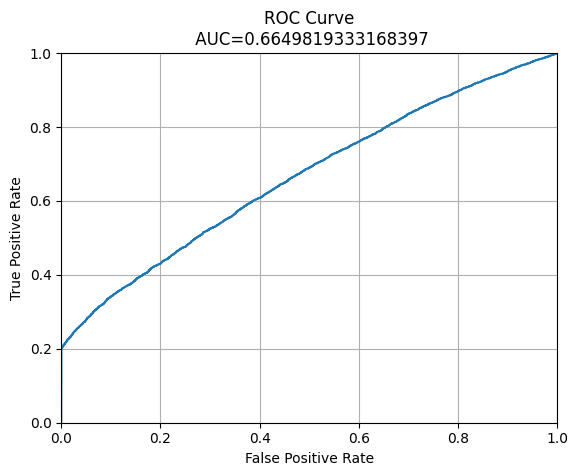

In [ ]:
logreg = LogisticRegression()
model_training(logreg, X_train, y_train)

plot_auc_curve(logreg, X_test, y_test)
Find_Optimal_Cutoff(logreg, X_test, y_test)
#print_accurcay_metrics(logreg, X_test, y_test, 0.65)

In [ ]:
#plot_auc_curve(logreg, X_train, y_train)
#Find_Optimal_Cutoff(logreg, X_train, y_train)
print_accurcay_metrics(logreg, X_train, y_train, 0.75)

Accurcay: 0.4488232151393302
AUC: 0.6682808272701504
Log Loss: 0.5384635121189049
Confusion Matrix:
 [[19704   460]
 [38743 12219]]
Recall: 0.23976688513009695
Precision: 0.9637195362410285


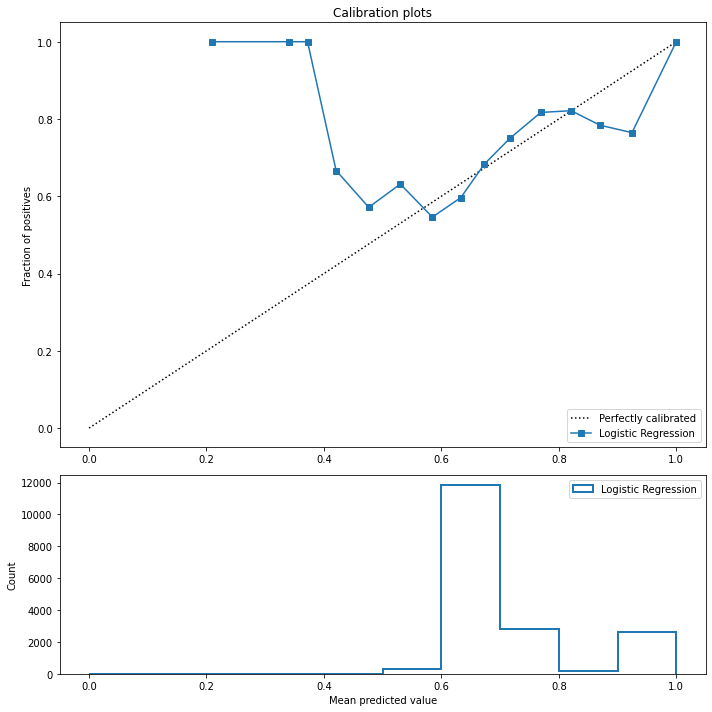

In [ ]:
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

plot_calibration(y_test, y_pred_prob, 20, "Logistic Regression")

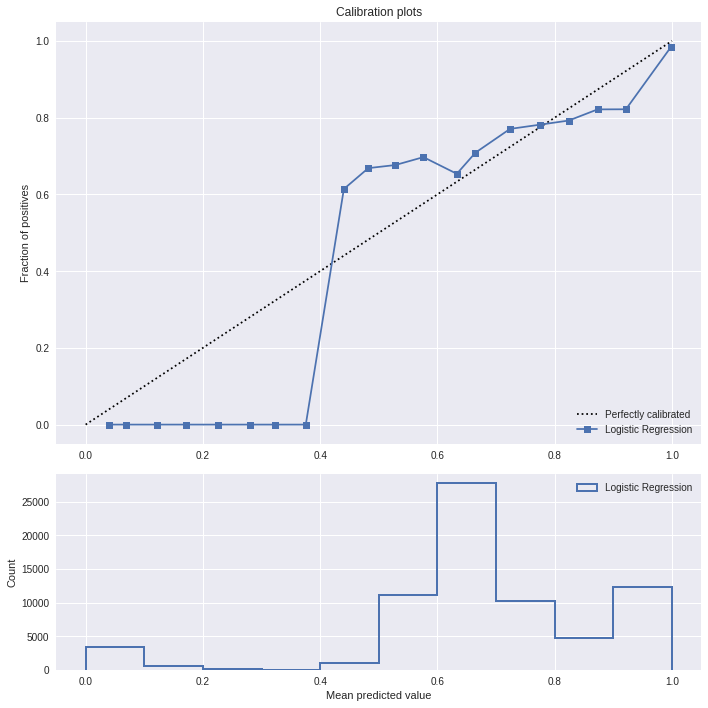

In [ ]:
y_pred_prob = logreg.predict_proba(X_train)[:, 1]

plot_calibration(y_train, y_pred_prob, 20, "Logistic Regression")

In [ ]:
print_accurcay_metrics(logreg, X_train, y_train, 0.65)

Accurcay: 0.650142001518432
AUC: 0.7198178626250189
Log Loss: 0.4933202962222927
Confusion Matrix:
 [[12358  7806]
 [17078 33884]]
Recall: 0.6648875632824457
Precision: 0.8127608539218037


**Fit Logistic regression with L2 regularization (Ridge)**

Optimal Cutoff: [0.5938946]
Accurcay: 0.5827241030255315
AUC: 0.715557014699968
Log Loss: 0.5875897044003854
Confusion Matrix:
 [[3950 1057]
 [6363 6412]]
Recall: 0.5019178082191781
Precision: 0.8584817244611059


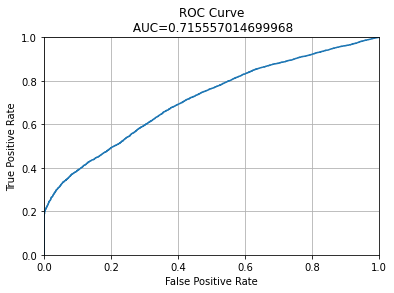

In [ ]:
ridge = RidgeClassifier(alpha=1.0)
model_training(ridge, X_train, y_train)

plot_auc_curve(ridge, X_test, y_test)
Find_Optimal_Cutoff(ridge, X_test, y_test)
print_accurcay_metrics(ridge, X_test, y_test, 0.61)

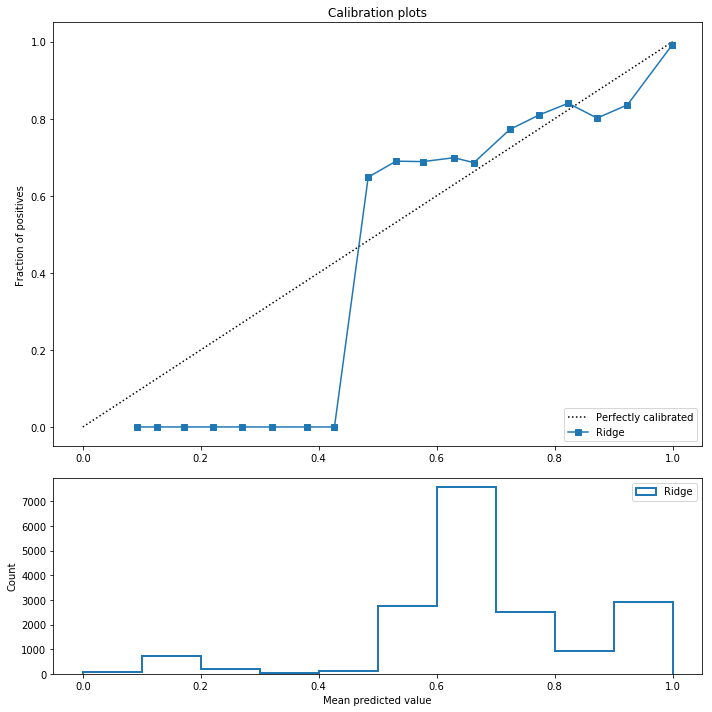

In [ ]:
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

plot_calibration(y_test, y_pred_prob, 20, "Ridge")

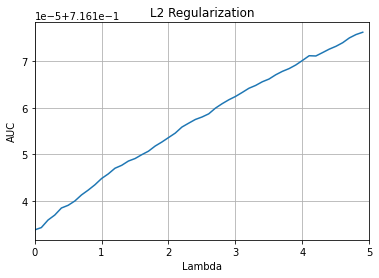

In [ ]:
alpha_range = np.arange(0.001, 5, 0.1)
scores = []
for lam in alpha_range:
  ridge = RidgeClassifier(alpha=lam)
  scores.append(cross_val_score(ridge, X_train, y_train, cv=5, scoring='roc_auc').mean())

plt.plot(alpha_range, scores)
plt.xlim([0.0, 5])
#plt.ylim([0.0, 1.0])
plt.title('L2 Regularization')
plt.xlabel('Lambda')
plt.ylabel('AUC')
plt.grid(True)

In [ ]:
scores

**Fit Logistic regression with L1 regularization (Lasso)**

Optimal Cutoff: [0.66990702]
Accurcay: 0.4600157462602632
AUC: 0.6667747110991774
Log Loss: 0.5355833896265285
Confusion Matrix:
 [[4829  178]
 [9424 3351]]
Recall: 0.2623091976516634
Precision: 0.949560782091244


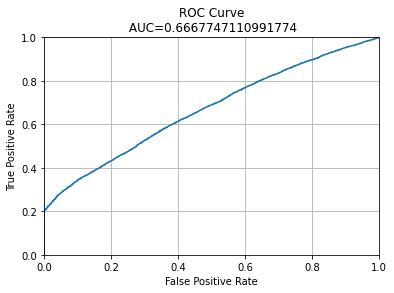

In [ ]:
lasso = LogisticRegression(C=1)
model_training(lasso, X_train, y_train)

plot_auc_curve(lasso, X_test, y_test)
Find_Optimal_Cutoff(lasso, X_test, y_test)
print_accurcay_metrics(lasso, X_test, y_test, 0.73)

In [ ]:
lambda_range = np.arange(0.001, 1, 0.1)
scores = []
for lam in lambda_range:
  lasso = LogisticRegression(C=1/lam)
  scores.append(cross_val_score(lasso, X_train, y_train, cv=5, scoring='roc_auc').mean())



In [ ]:
scores

[0.6683219890033764,
 0.6683168413027041,
 0.6683246115998503,
 0.6683101780754803,
 0.6683207288207951,
 0.6683230789656298,
 0.668318017837979,
 0.6683135277288075,
 0.6683214634903797,
 0.6683237504307808]

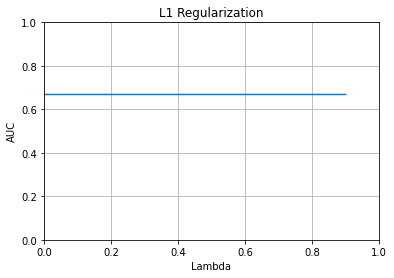

In [ ]:
plt.plot(lambda_range, scores)
plt.xlim([0.0, 1])
plt.ylim([0.0, 1.0])
plt.title('L1 Regularization')
plt.xlabel('Lambda')
plt.ylabel('AUC')
plt.grid(True)

**2-degree Polynomial Features**

In [ ]:
poly = PolynomialFeatures(2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [ ]:
print(X_test.shape)
print(X_test_poly.shape)

(17782, 30)
(17782, 496)


Optimal Cutoff: [0.50000056]
Accurcay: 0.4260488134068159
AUC: 0.6314739638478732
Log Loss: 0.592997208680826
Confusion Matrix:
 [[ 5007     0]
 [10206  2569]]
Recall: 0.2010958904109589
Precision: 1.0


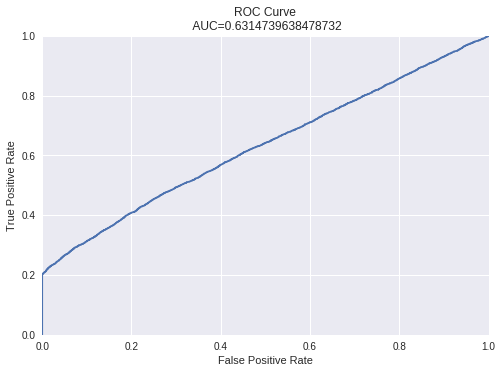

In [ ]:
logreg_poly = LogisticRegression()
model_training(logreg_poly, X_train_poly, y_train)

plot_auc_curve(logreg_poly, X_test_poly, y_test)
Find_Optimal_Cutoff(logreg_poly, X_test_poly, y_test)
print_accurcay_metrics(logreg_poly, X_test_poly, y_test, 0.75)


Optimal Cutoff: [0.50000056]
Accurcay: 0.4265528779911706
AUC: 0.6291482466513103
Log Loss: 0.593985800009206
Confusion Matrix:
 [[20164     0]
 [40787 10175]]
Recall: 0.19965856912993996
Precision: 1.0


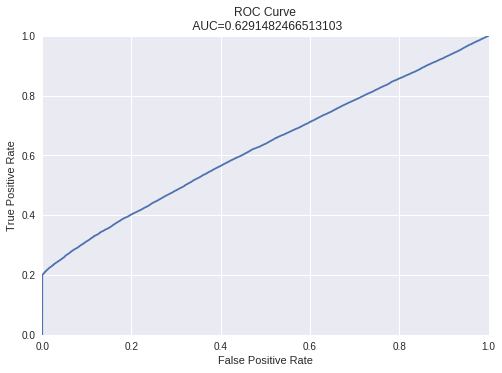

In [ ]:
plot_auc_curve(logreg_poly, X_train_poly, y_train)
Find_Optimal_Cutoff(logreg_poly, X_train_poly, y_train)
print_accurcay_metrics(logreg_poly, X_train_poly, y_train, 0.75)


In [ ]:
print_accurcay_metrics(logreg_poly, X_train_poly, y_train, 0.75)


Accurcay: 0.4265528779911706
AUC: 0.6291482466513103
Log Loss: 0.593985800009206
Confusion Matrix:
 [[20164     0]
 [40787 10175]]
Recall: 0.19965856912993996
Precision: 1.0


Optimal Cutoff: [0.6066277]
Accurcay: 0.707906872117872
AUC: 0.7856372976072247
Log Loss: 0.5413509330047691
Confusion Matrix:
 [[3267 1740]
 [3454 9321]]
Recall: 0.729628180039139
Precision: 0.842690534309737


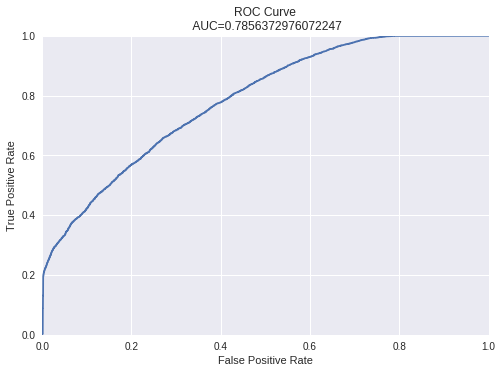

In [ ]:
ridge_poly = RidgeClassifier(alpha=1.0)
model_training(ridge_poly, X_train_poly, y_train)

plot_auc_curve(ridge_poly, X_test_poly, y_test)
Find_Optimal_Cutoff(ridge_poly, X_test_poly, y_test)
print_accurcay_metrics(ridge_poly, X_test_poly, y_test, 0.6)

Optimal Cutoff: [0.72400387]
Accurcay: 0.6847373748734675
AUC: 0.7896286099656176
Log Loss: 0.4413692013788498
Confusion Matrix:
 [[3556 1451]
 [4155 8620]]
Recall: 0.6747553816046967
Precision: 0.8559229470757621


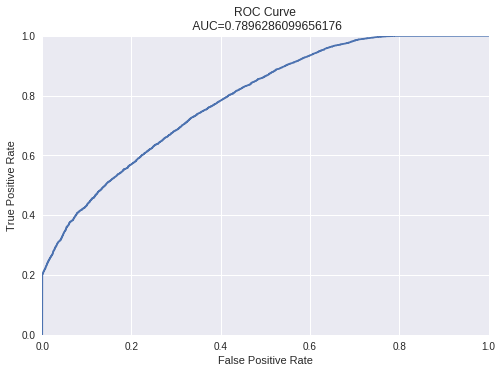

In [ ]:
lasso_poly = LogisticRegression(penalty='l1', C=1)
model_training(lasso_poly, X_train_poly, y_train)

plot_auc_curve(lasso_poly, X_test_poly, y_test)
Find_Optimal_Cutoff(lasso_poly, X_test_poly, y_test)
print_accurcay_metrics(lasso_poly, X_test_poly, y_test, 0.73)